In [1]:
# ============================================
#  TEXT SIMILARITY & EXTRACTIVE SUMMARIZATION
# ============================================

# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import nltk
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

                                                text  category
0  Wall St. Bears Claw Back Into the Black (Reute...         2
1  Carlyle Looks Toward Commercial Aerospace (Reu...         2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...         2
3  Iraq Halts Oil Exports from Main Southern Pipe...         2
4  Oil prices soar to all-time record, posing new...         2
Dataset shape: (120000, 2)
Average article length: 37.861370534671956


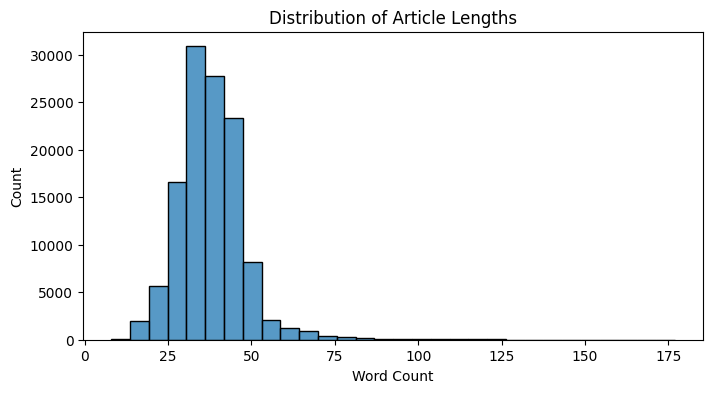

Sample article:

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [4]:
#Step 2: Data Preparation & Exploration
#  FIXED DATASET LOADING SECTION

!pip install datasets
from datasets import load_dataset
import pandas as pd

# Load AG News dataset
dataset = load_dataset("ag_news", split="train")

# Convert to DataFrame
df = pd.DataFrame(dataset)
df.rename(columns={"text": "text", "label": "category"}, inplace=True)

print(df.head())
print("Dataset shape:", df.shape)

# Drop missing or duplicates
df.dropna(inplace=True)
df.drop_duplicates(subset='text', inplace=True)

# Remove very short or empty docs
df = df[df['text'].str.len() > 100]

# Basic exploration
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print("Average article length:", df['word_count'].mean())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df['word_count'], bins=30)
plt.title("Distribution of Article Lengths")
plt.xlabel("Word Count")
plt.show()

print("Sample article:\n")
print(df['text'].iloc[0][:1000])


In [6]:
#necessary installation for preprocessing
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
#Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\s+', ' ', text)
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
df['sentences'] = df['text'].apply(sent_tokenize)

print(df[['text','clean_text']].head(1))


                                                text  \
0  Wall St. Bears Claw Back Into the Black (Reute...   

                                          clean_text  
0  wall st bear claw back black reuters reuters s...  


In [8]:
# TF-IDF Representation for Sentences
def compute_tfidf(sentences):
    tfidf = TfidfVectorizer(max_features=5000)
    tfidf_matrix = tfidf.fit_transform(sentences)
    return tfidf, tfidf_matrix

# Example for one article
article_sentences = df['sentences'].iloc[0]
tfidf, tfidf_matrix = compute_tfidf(article_sentences)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)


TF-IDF Matrix Shape: (1, 21)


In [9]:
#TF-IDF Based Importance
sentence_scores = tfidf_matrix.sum(axis=1).flatten().tolist()
scored_sentences = list(zip(article_sentences, sentence_scores))
sorted_scored_sentences = sorted(scored_sentences, key=lambda x: x[1], reverse=True)

print("Top 5 important sentences:\n")
for s, score in sorted_scored_sentences[:5]:
    print("-", s.strip(), "\n")


Top 5 important sentences:

- Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. 



In [10]:
#TextRank Algorithm (Graph-based)
import networkx as nx

# Create similarity matrix
sim_mat = cosine_similarity(tfidf_matrix)
nx_graph = nx.from_numpy_array(sim_mat)
scores = nx.pagerank(nx_graph)

# Rank sentences
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(article_sentences)), reverse=True)
print("\nTop 5 TextRank Sentences:\n")
for i, (score, sent) in enumerate(ranked_sentences[:5]):
    print(f"{i+1}. {sent.strip()}")



Top 5 TextRank Sentences:

1. Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [11]:
#Summary Generation
def generate_summary(sentences, method='tfidf', top_n=5):
    tfidf, matrix = compute_tfidf(sentences)
    if method == 'tfidf':
        scores = matrix.sum(axis=1).flatten().tolist()
    elif method == 'textrank':
        sim = cosine_similarity(matrix)
        graph = nx.from_numpy_array(sim)
        pr = nx.pagerank(graph)
        scores = [pr[i] for i in range(len(sentences))]

    # Rank and pick top sentences
    ranked = sorted(zip(sentences, scores), key=lambda x: x[1], reverse=True)
    top_sentences = [s for s, _ in ranked[:top_n]]

    # Maintain original order
    summary = ' '.join([s for s in sentences if s in top_sentences])
    return summary

# Generate and display
article = df['sentences'].iloc[2]
summary = generate_summary(article, method='textrank', top_n=5)
print("📰 Original:\n", df['text'].iloc[2][:1000])
print("\n✂️ Summary:\n", summary)


📰 Original:
 Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.

✂️ Summary:
 Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.


In [12]:
#Redundancy Check & Sentence Similarity
def remove_redundant_sentences(summary_sentences, threshold=0.75):
    clean_summary = []
    tfidf, matrix = compute_tfidf(summary_sentences)
    sim = cosine_similarity(matrix)
    for i, s in enumerate(summary_sentences):
        if all(sim[i][j] < threshold for j in range(i)):
            clean_summary.append(s)
    return clean_summary

# Example redundancy reduction
sent_list = sent_tokenize(summary)
final_sentences = remove_redundant_sentences(sent_list)
final_summary = ' '.join(final_sentences)

print("\n🧹 Final Summary after redundancy check:\n", final_summary)



🧹 Final Summary after redundancy check:
 Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.


In [15]:
#Add a progress bar for long datasets
from tqdm import tqdm

# Run summarization on 10 random articles for speed
subset = df.sample(10, random_state=42).reset_index(drop=True)

summaries = []

for i in tqdm(range(len(subset))):
    sentences = subset['sentences'].iloc[i]
    # ✅ Use TF-IDF instead of TextRank for faster performance
    summary = generate_summary(sentences, method='tfidf', top_n=4)
    summaries.append(summary)

subset['generated_summary'] = summaries

# Save results for report
subset[['text', 'generated_summary']].to_csv('summaries_output.csv', index=False)

# Display first few
subset[['text', 'generated_summary']].head()


100%|██████████| 10/10 [00:00<00:00, 105.03it/s]


,text,generated_summary
0,Fed Seen Sticking to Measured Rate Raises (Reu...,Fed Seen Sticking to Measured Rate Raises (Reu...
1,Strategies for a Sideways Market WASHINGTON (...,Strategies for a Sideways Market WASHINGTON (...
2,Nucleus Software buys 25.1 in GMAC Nucleus Sof...,Nucleus Software buys 25.1 in GMAC Nucleus Sof...
3,BHP Billiton to award shareholders Announcing ...,BHP Billiton to award shareholders Announcing ...
4,Suspected Mastermind Held in Pakistan (AP) AP ...,Suspected Mastermind Held in Pakistan (AP) AP ...


In [16]:
from tqdm import tqdm
summaries = []

for i in tqdm(range(len(df))):
    sentences = df['sentences'].iloc[i]
    summary = generate_summary(sentences, method='textrank', top_n=4)
    summaries.append(summary)

df['generated_summary'] = summaries


100%|██████████| 119924/119924 [07:06<00:00, 280.91it/s]


In [17]:
#Limit article length & remove redundancy to make it visibly “shorter” and ready for your report
def shorten_summary(summary_text, max_sentences=2):
    sentences = nltk.sent_tokenize(summary_text)
    return ' '.join(sentences[:max_sentences])

subset['short_summary'] = subset['generated_summary'].apply(lambda x: shorten_summary(x, 2))
subset[['text', 'short_summary']].head()


,text,short_summary
0,Fed Seen Sticking to Measured Rate Raises (Reu...,Fed Seen Sticking to Measured Rate Raises (Reu...
1,Strategies for a Sideways Market WASHINGTON (...,Strategies for a Sideways Market WASHINGTON (...
2,Nucleus Software buys 25.1 in GMAC Nucleus Sof...,Nucleus Software buys 25.1 in GMAC Nucleus Sof...
3,BHP Billiton to award shareholders Announcing ...,BHP Billiton to award shareholders Announcing ...
4,Suspected Mastermind Held in Pakistan (AP) AP ...,Suspected Mastermind Held in Pakistan (AP) AP ...


In [18]:
#Compare Original vs Summary Length
subset['original_length'] = subset['text'].apply(lambda x: len(x.split()))
subset['summary_length'] = subset['short_summary'].apply(lambda x: len(x.split()))
subset['reduction_%'] = ((subset['original_length'] - subset['summary_length']) / subset['original_length']) * 100

subset[['original_length', 'summary_length', 'reduction_%']].head()


,original_length,summary_length,reduction_%
0,45,45,0.0
1,27,27,0.0
2,41,41,0.0
3,32,32,0.0
4,46,46,0.0


In [19]:
#Save final summarized output
subset[['text', 'short_summary', 'reduction_%']].to_csv('final_summaries.csv', index=False)
print("✅ Saved as final_summaries.csv")


✅ Saved as final_summaries.csv
